In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime


In [4]:
sip=pd.read_csv("data/processed/04_monthly_sip_inflows.csv")
sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
 6   date_key                   48 non-null     int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 2.8+ KB


In [5]:
print(sip.shape)

print(sip["month"].min())
print(sip["month"].max())

print(
    sip["sip_inflow_crore"].max()
)

(48, 7)
2022-01
2025-12
31002


## SIP Inflow Trend Analysis (2022–2025)

Systematic Investment Plan (SIP) inflows were analyzed on a
monthly basis from January 2022 through December 2025.

The analysis highlights the strong growth in retail investor
participation, culminating in a record SIP inflow of
₹31,002 crore in December 2025.

In [6]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

In [7]:
peak_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

peak_month = peak_row["month"]
peak_value = peak_row["sip_inflow_crore"]

print(peak_month)
print(peak_value)

2025-12-01 00:00:00
31002


In [11]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    }
)

fig.add_annotation(
    x=peak_month,
    y=peak_value,
    text="All-Time High<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-60
)

fig.update_layout(
    template="plotly_white",
    height=650,
    hovermode="x unified"
)

fig.update_traces(
    line_width=3
)
fig.add_scatter(
    x=[peak_month],
    y=[peak_value],
    mode="markers",
    marker=dict(
        size=12,
        symbol="star"
    ),
    name="Record High"
)

fig.show()

## Category-wise Net Inflow Heatmap

The heatmap visualizes monthly net inflows across 12 mutual
fund categories from April 2024 to March 2025.

Darker shades indicate stronger investor inflows, helping
identify periods of heightened interest across categories.

In [13]:
cat=pd.read_csv("data/processed/05_category_inflows.csv")
print(cat.shape)

cat.head()

cat.info()

(144, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
 3   date_key          144 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 4.6+ KB


In [14]:
cat["category"].nunique()

12

In [17]:
cat["month"].min()



'2024-04'

In [16]:
cat["month"].max()

'2025-03'

In [18]:
cat["month"] = pd.to_datetime(
    cat["month"]
)

In [20]:
heatmap_df = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
heatmap_df.shape

(12, 12)

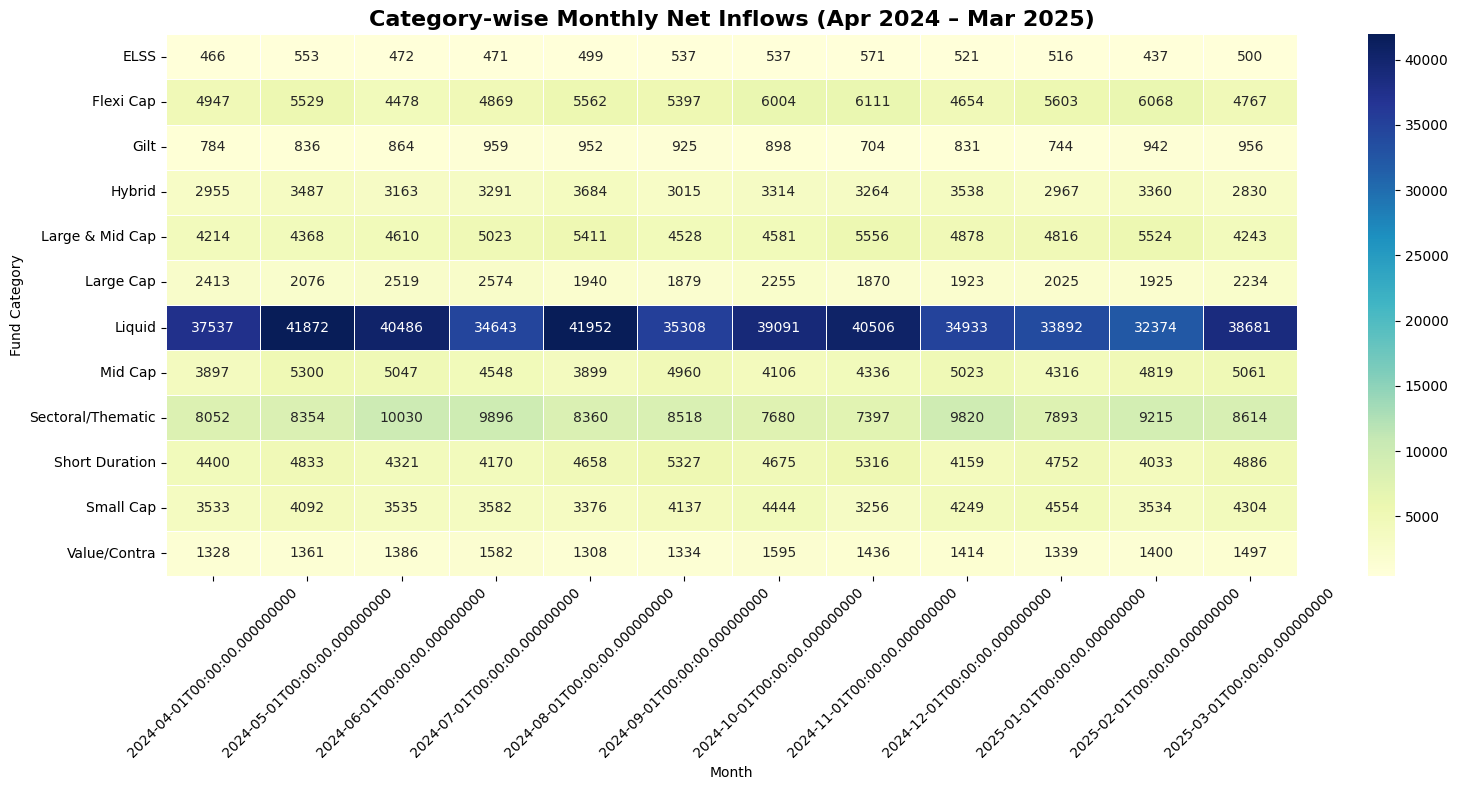

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Category-wise Monthly Net Inflows (Apr 2024 – Mar 2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [25]:
cat.groupby("category")[
    "net_inflow_crore"
].sum().sort_values(
    ascending=False
)

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

In [27]:
cat["category"].value_counts()



category
ELSS                 12
Flexi Cap            12
Gilt                 12
Hybrid               12
Large & Mid Cap      12
Large Cap            12
Liquid               12
Mid Cap              12
Sectoral/Thematic    12
Short Duration       12
Small Cap            12
Value/Contra         12
Name: count, dtype: int64

In [28]:
cat["net_inflow_crore"].min()

np.float64(437.0)

In [29]:
cat.groupby("category")[
    "net_inflow_crore"
].sum().sort_values(
    ascending=False
)


category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

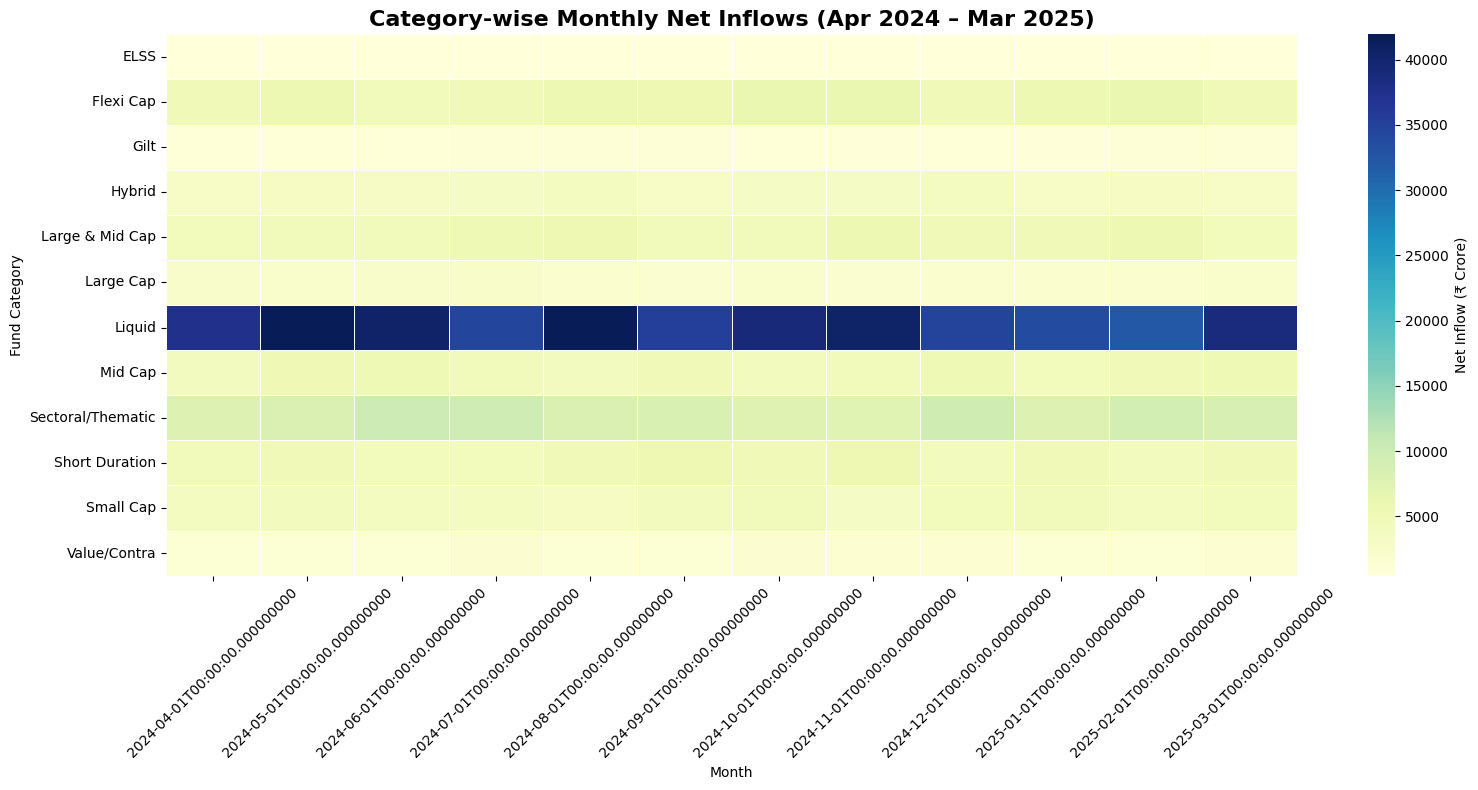

In [30]:
cat["month"] = pd.to_datetime(cat["month"])

heatmap_df = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label":"Net Inflow (₹ Crore)"}
)

plt.title(
    "Category-wise Monthly Net Inflows (Apr 2024 – Mar 2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [31]:
txn = pd.read_csv(
    "data/processed/08_investor_transactions.csv"
)

print(txn.shape)

txn.head()

txn.info()

(32778, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      32778 non-null  int64  
 1   investor_id         32778 non-null  object 
 2   transaction_date    32778 non-null  object 
 3   amfi_code           32778 non-null  int64  
 4   transaction_type    32778 non-null  object 
 5   amount_inr          32778 non-null  int64  
 6   state               32778 non-null  object 
 7   city                32778 non-null  object 
 8   city_tier           32778 non-null  object 
 9   age_group           32778 non-null  object 
 10  gender              32778 non-null  object 
 11  annual_income_lakh  32778 non-null  float64
 12  payment_mode        32778 non-null  object 
 13  kyc_status          32778 non-null  object 
 14  date_key            32778 non-null  int64  
dtypes: float64(1), int64(4), object(10)
memor

In [33]:
print("Columns:", txn.columns.tolist(), "\n")

print("Age group counts:\n", txn["age_group"].value_counts(), "\n")

print("Gender counts:\n", txn["gender"].value_counts(), "\n")

print("SIP amount stats:\n", txn["amount_inr"].describe())

Columns: ['transaction_id', 'investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'date_key'] 

Age group counts:
 age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64 

Gender counts:
 gender
Male      21809
Female    10969
Name: count, dtype: int64 

SIP amount stats:
 count     32778.000000
mean     107437.318628
std      150415.905084
min         400.000000
25%        3153.000000
50%       17782.500000
75%      189324.250000
max      597498.000000
Name: amount_inr, dtype: float64


In [34]:
txn["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [38]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
]
txn["transaction_type"].value_counts()


transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [40]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
].copy()
print(sip_txn.shape)

sip_txn["age_group"].value_counts()

(19716, 15)


age_group
26-35    8063
36-45    4926
18-25    2949
46-55    2300
56+      1478
Name: count, dtype: int64

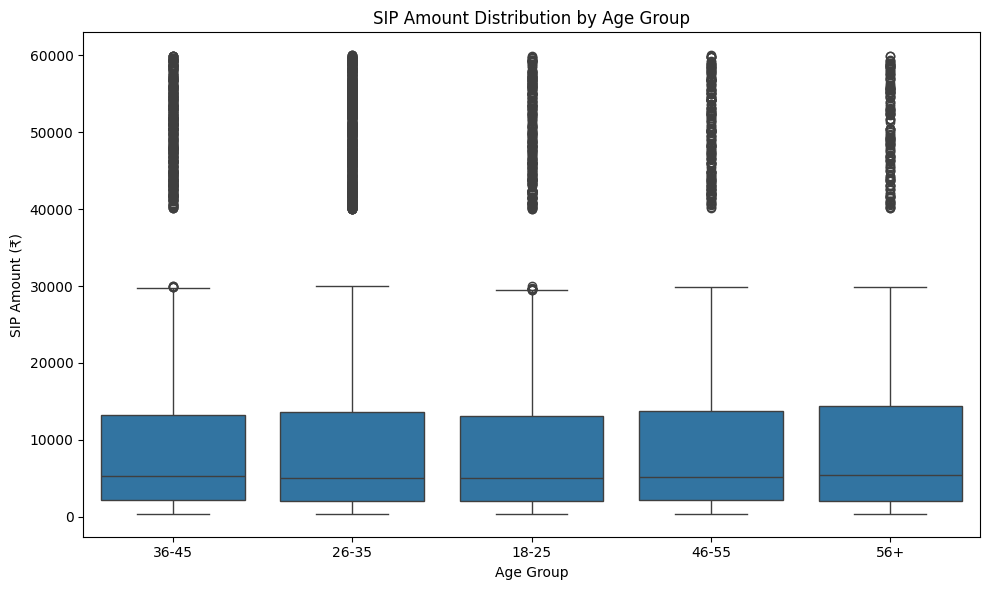

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()
plt.show()

In [42]:
sip_txn.groupby("age_group")["amount_inr"].agg(
    ["count","mean","median","min","max"]
).round(2)

,count,mean,median,min,max
age_group,,,,,
18-25,2949,10953.07,5020.0,401,59904
26-35,8063,10986.90,5070.0,400,59998
36-45,4926,10885.76,5250.0,400,59928
46-55,2300,11136.76,5136.0,400,59988
56+,1478,11574.92,5420.5,406,59960


In [45]:
age_dist = txn["age_group"].value_counts()
age_dist

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

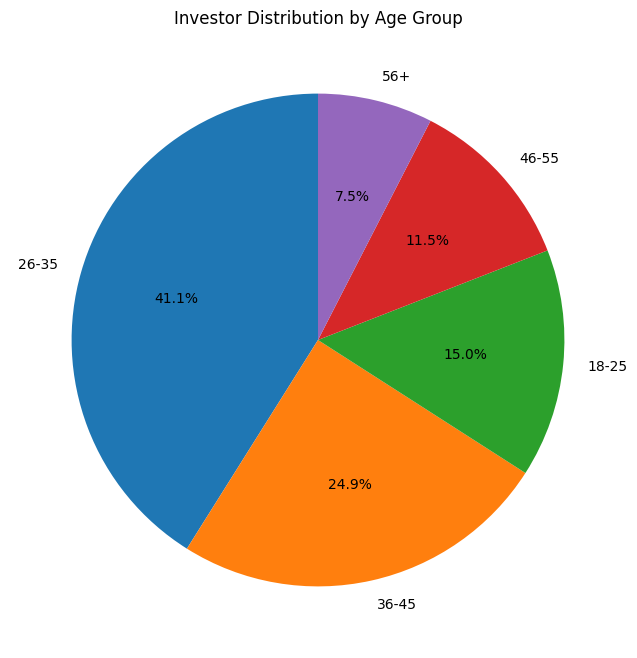

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.show()

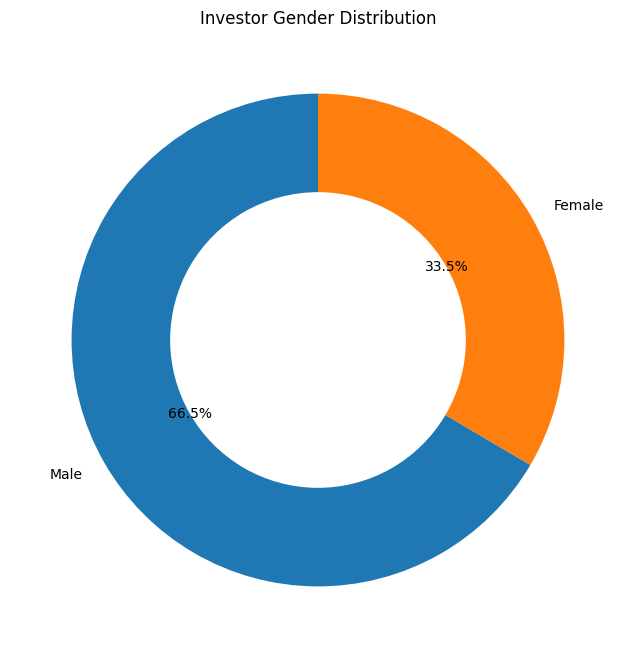

In [48]:
gender_dist = txn["gender"].value_counts()
gender_dist
plt.figure(figsize=(8,8))

plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Investor Gender Distribution")

plt.show()


## Geographic Distribution of SIP Investments

This analysis examines the geographic distribution of SIP investments across Indian states and city tiers.

State-wise aggregation highlights regional participation patterns, while the T30/B30 analysis compares investment activity between the top 30 cities and the rest of India.

In [51]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
].copy()
print(sip_txn.shape)

(19716, 15)


In [52]:
state_sip = (
    sip_txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip

state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Haryana           18176696
Karnataka         17696903
Uttar Pradesh     17534858
West Bengal       17495769
Delhi             17113608
Rajasthan         16544233
Maharashtra       16445629
Name: amount_inr, dtype: int64

In [53]:
top_states = state_sip.head(10)

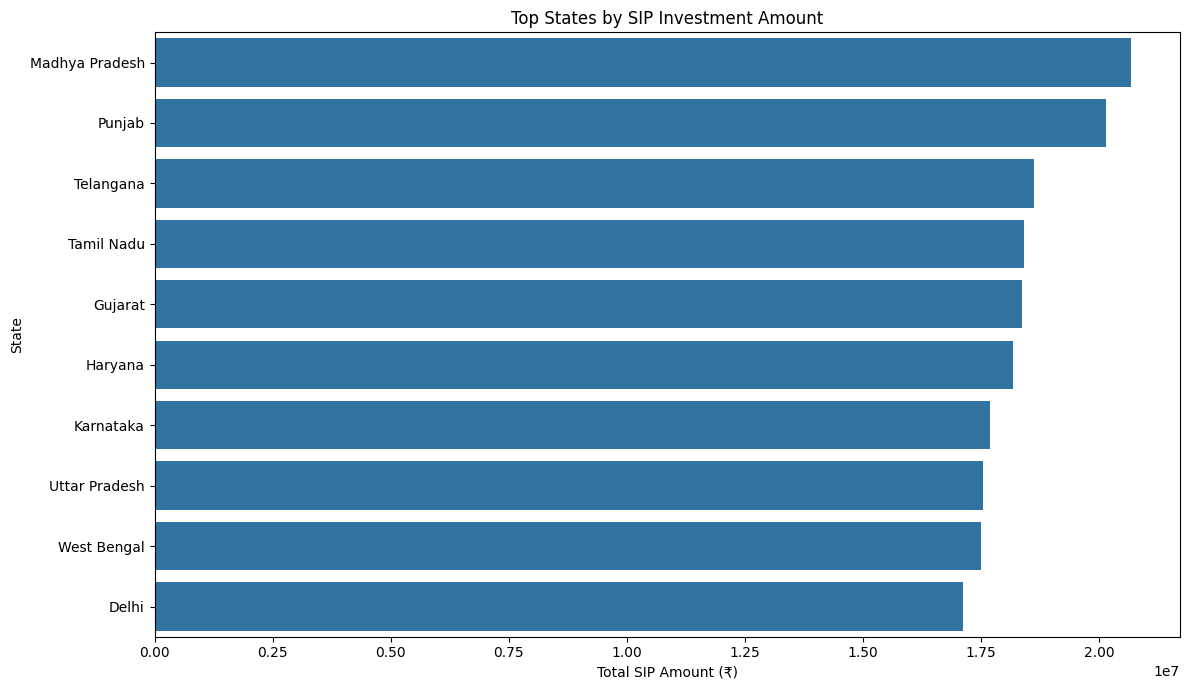

In [54]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title(
    "Top States by SIP Investment Amount"
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

In [55]:
sip_txn["city_tier"].value_counts()

city_tier
T30    13123
B30     6593
Name: count, dtype: int64

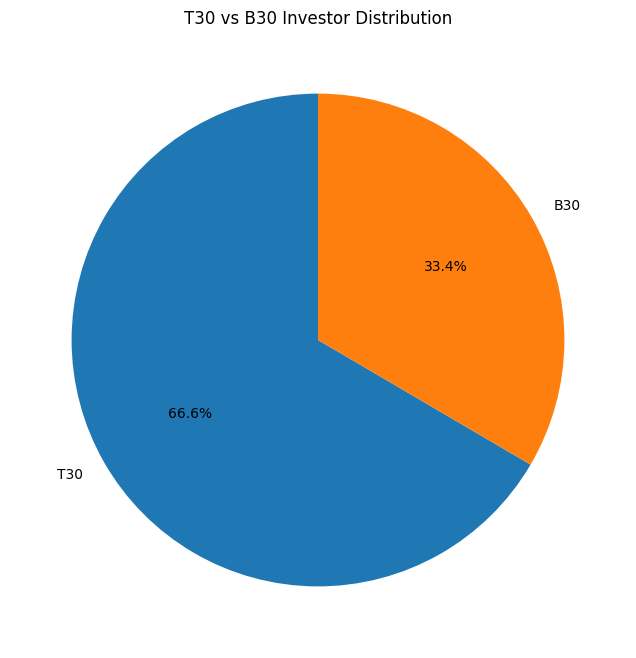

In [57]:
plt.figure(figsize=(8,8))

tier_dist = sip_txn["city_tier"].value_counts()

plt.pie(
    tier_dist,
    labels=tier_dist.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 Investor Distribution"
)

plt.show()

In [58]:
tier_sip = (
    sip_txn.groupby("city_tier")["amount_inr"]
    .sum()
)

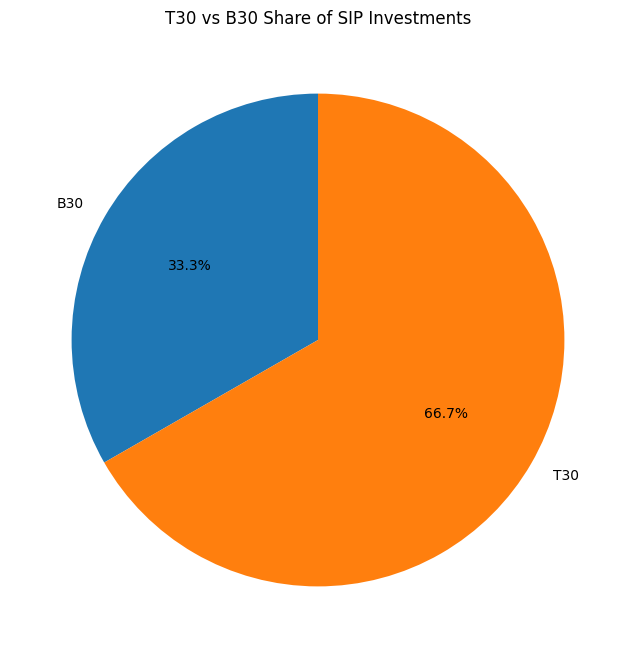

In [59]:
plt.figure(figsize=(8,8))

plt.pie(
    tier_sip,
    labels=tier_sip.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 Share of SIP Investments"
)

plt.show()

In [60]:
state_sip = (
    sip_txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip.head(15)

state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Haryana           18176696
Karnataka         17696903
Uttar Pradesh     17534858
West Bengal       17495769
Delhi             17113608
Rajasthan         16544233
Maharashtra       16445629
Name: amount_inr, dtype: int64

In [ ]:
folio = pd.read_csv(
    "data/processed/06_industry_folio_count.csv"
)
print(folio.shape)
folio.info()

(21, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
 6   date_key             21 non-null     int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 1.3+ KB


In [64]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore,date_key
0,2022-01,13.26,9.28,1.86,0.80,1.33,20220101
1,2022-04,13.91,9.74,1.95,0.83,1.39,20220401
2,2022-07,13.85,9.69,1.94,0.83,1.38,20220701
3,2022-10,14.12,9.88,1.98,0.85,1.41,20221001
4,2023-01,14.81,10.37,2.07,0.89,1.48,20230101


In [ ]:
print(folio.shape)
print(folio.iloc[0])
print(folio.iloc[-1])

(21, 7)
month                   2022-01
total_folios_crore        13.26
equity_folios_crore        9.28
debt_folios_crore          1.86
hybrid_folios_crore         0.8
others_folios_crore        1.33
date_key               20220101
Name: 0, dtype: object
month                   2025-12
total_folios_crore        26.12
equity_folios_crore       18.28
debt_folios_crore          3.66
hybrid_folios_crore        1.57
others_folios_crore        2.61
date_key               20251201
Name: 20, dtype: object


In [66]:
folio[["month","total_folios_crore"]]


,month,total_folios_crore
0,2022-01,13.26
1,2022-04,13.91
2,2022-07,13.85
3,2022-10,14.12
4,2023-01,14.81
5,2023-04,15.54
6,2023-07,16.28
7,2023-10,16.72
8,2024-01,17.78
9,2024-04,18.85


In [71]:
import plotly.express as px

folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Count Growth (2022–2025)",
    labels={
        "month":"Month",
        "total_folios_crore":"Folios (Crore)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=650
)

fig.update_traces(
    line_width=4
)


# now the bleow lines are 
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text="13.26 Cr<br>Jan 2022",
    showarrow=True
)

fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text="26.12 Cr<br>Dec 2025",
    showarrow=True
)

milestones = [15,20,25]

for milestone in milestones:

    row = folio[
        folio["total_folios_crore"] >= milestone
    ].iloc[0]

    fig.add_annotation(
        x=row["month"],
        y=row["total_folios_crore"],
        text=f"{milestone} Cr Milestone",
        showarrow=True,
        arrowhead=2
    )
    fig.show()

SyntaxError: invalid character '—' (U+2014) (1545528461.py, line 1)